# Projeto 2 - Ciencia dos Dados

### --- Grupo 6 ---

##### - João Victor Ribeiro Lopes
##### - Victor Lucius
##### - Alline Oliveira
##### - Isaac Reis
___


Importando Bibliotecas:

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import os

In [2]:
print('Esperamos trabalhar no diretório')
print(os.getcwd())

Esperamos trabalhar no diretório
c:\Users\joaos\Downloads\CDados - Jv\Projeto 2\Projeto-2-Cdados


___

# 1 - Introdução 

O Exame Nacional do Ensino Médio (ENEM) foi instituído em 1998 com o objetivo de avaliar o desempenho escolar dos estudantes ao término da educação básica. Em 2009, o exame aperfeiçoou sua metodologia e consolidou-se como o principal mecanismo de acesso à educação superior no Brasil. No entanto, para entender o ENEM em sua totalidade, é preciso enxergá-lo não apenas como uma prova de 180 questões e uma redação, mas como um mecanismo complexo que reflete a realidade social do Brasil, na qual indicadores socioeconômicos, demográficos e geográficos impactam profundamente a média final do participante.

Condições socioeconômicas de estudantes que concorrem ao Enem afetam em até 85% o resultado final no exame. É o que mostra estudo desenvolvido pelo cientista de dados e mestre em Economia pela Universidade de Brasília, Leonardo Sales. A pesquisa leva em contas fatores como a renda de cada aluno, se a escola é pública ou privada e se a família incentiva ou não os estudos.
UFMG, 8 nov. 2018. Disponível em: https://www3.ufmg.br/comunicacao/noticias/fatores-socioeconomicos-determinam-nota-do-enem-diz-estudo. Acesso em: 20 abr. 2026. 

Essa reflexão se torna ainda mais urgente quando observamos cursos de altíssima concorrência, como *Direito. Nesses cenários, a aprovação no SiSU exige uma excelência direcionada, pois a nota de corte é definida por uma **média ponderada* — atribuindo peso máximo (3) às áreas de Redação, Linguagens e Ciências Humanas, e peso menor (1) para Matemática e Ciências da Natureza. Com essa métrica, cada décimo na nota final é decisivo, evidenciando que o desempenho do candidato raramente é fruto apenas do seu esforço individual, mas sim do ambiente e das oportunidades que o cercam.

Neste projeto, adicionamos a essa equação um fator histórico sem precedentes: o ano de *2020, que marcou o ápice da pandemia de COVID-19 e escancarou a desigualdade na educação básica brasileira. Em contraste, analisamos **2023*, que representa o cenário de retomada pós-pandêmica.

Para o desenvolvimento deste projeto, utilizamos a análise de microdados, que representam um nível mais  detalhado de um levantamento estatístico. Enquanto dados agregados oferecem apenas visões generalistas, os microdados permitem acessar a unidade individual da pesquisa: no caso do ENEM, cada linha da base de dados corresponde às respostas e ao desempenho específico de um único candidato.
Essa escala de detalhamento é fundamental, pois possibilita a filtragem do público-alvo desejado. Além disso, os microdados são a base para o cálculo da Média Ponderada do ENEM (MPE), que atua como a nossa variável principal (target) e também é possível usufruir da análise de indicadores macroeconômicos na qual permite investigar se o contexto econômico e social onde o aluno vive e estuda impacta diretamente o seu desempenho e suas chances de ingresso em cursos de alta concorrência. Foi utilizado o  PIB Municipal que representa a soma de todos os bens e serviços finais produzidos em um município. Ele funciona como um termômetro da riqueza da cidade onde a escola do candidato está localizada e Índice FIRJAN que  acompanha anualmente o desenvolvimento humano, econômico e social das cidades com base em três pilares fundamentais: emprego, renda, educação e saúde.

Nosso objetivo é responder a uma pergunta central: *Até que ponto os indicadores macroeconômicos de um município e os dados socioeconômicos do candidato conseguem prever a sua Nota Ponderada para o curso de Direito no ENEM?*
___

# 2 - EXPORTANDO DADOS

Os dados sobre o ENEM foram retirados do INEP, os dados apresentam formato CSV e são acompanhados por um dicionário, já que algumas informações são substituídas por códigos para deixar as bases de dados mais leves. Os dados do desenvolvimento municipal FIRJAN foram retirados do site oficial do FIRJAN em formato CSV, os dados do PIB foram extraídos do IBGE, formato xlsx.

In [3]:
# Carregando os dados
enem2023 = pd.read_csv('../microdados_enem_2023/DADOS/MICRODADOS_ENEM_2023.csv',encoding='ISO-8859-1',sep=';')

In [46]:
print(f'Número de linhas: {enem2023.shape[0]}\nNúmero de colunas: {enem2023.shape[1]}')

Número de linhas: 3933955
Número de colunas: 76


In [47]:
enem2020 = pd.read_csv('../microdados_enem_2020/DADOS/MICRODADOS_ENEM_2020.csv',encoding='ISO-8859-1',sep=';')

KeyboardInterrupt: 

In [6]:
print(f'Número de linhas: {enem2020.shape[0]}\nNúmero de colunas: {enem2020.shape[1]}')

Número de linhas: 5783109
Número de colunas: 76


In [7]:
firjan = pd.read_csv('../Serie-Historica-IFDM-2013-a-2023(IFDM Geral).csv',encoding='ISO-8859-1',sep=';')

In [8]:
print(f'Número de linhas: {firjan.shape[0]}\nNúmero de colunas: {firjan.shape[1]}')

Número de linhas: 5570
Número de colunas: 36


In [9]:
pib = pd.read_excel('../PIB dos Municípios - base de dados 2010-2023.xlsx')

In [10]:
print(f'Número de linhas: {pib.shape[0]}\nNúmero de colunas: {pib.shape[1]}')

Número de linhas: 77965
Número de colunas: 43


___
# FILTRANDO DADOS

Primeiro, excluímos as linhas que dificultariam a análise: Treineiros, Faltou em alguma prova, redação irregular (receberam 0), que não estavam concluindo o ensino médio no ano, não eram brasileiros, ensino não convencional (Educação Especial - Modalidade Substitutiva), não responderam o município onde estudaram, não responderam o questionário socioeconômico. Depois, excluímos as colunas de pouca relevância: Todos que já foram filtrados para um único valor, respostas na prova, gabarito, nota indivídual da redação, código da prova...

In [11]:
#removendo linhas desnecessárias:
enem2020filtrado = enem2020[
    (enem2020['IN_TREINEIRO'] == 0) &
    (enem2020['TP_PRESENCA_CN'] == 1) &
    (enem2020['TP_PRESENCA_CH'] == 1) &
    (enem2020['TP_PRESENCA_LC'] == 1) &
    (enem2020['TP_PRESENCA_MT'] == 1) &
    (enem2020['TP_STATUS_REDACAO'] == 1) &
    (enem2020['TP_ST_CONCLUSAO'] == 2) &
    (enem2020['TP_NACIONALIDADE'] == 1) &
    (enem2020['TP_ENSINO'] == 1) &
    (enem2020['NO_MUNICIPIO_ESC'].notna()) &
    (enem2020['Q001'].notna())
]
enem2023filtrado = enem2023[
    (enem2023['IN_TREINEIRO'] == 0) &
    (enem2023['TP_PRESENCA_CN'] == 1) &
    (enem2023['TP_PRESENCA_CH'] == 1) &
    (enem2023['TP_PRESENCA_LC'] == 1) &
    (enem2023['TP_PRESENCA_MT'] == 1) &
    (enem2023['TP_STATUS_REDACAO'] == 1) &
    (enem2023['TP_ST_CONCLUSAO'] == 2) &
    (enem2023['TP_NACIONALIDADE'] == 1) &
    (enem2023['TP_ENSINO'] == 1) &
    (enem2023['NO_MUNICIPIO_ESC'].notna()) &
    (enem2023['Q001'].notna())
]
#removendo colunas desnecessárias:
cols = [
    'TP_SEXO',              # feature1
    'TP_COR_RACA',          # feature2
    'TP_ESCOLA',            # feature3
    'NO_MUNICIPIO_ESC',
    'CO_MUNICIPIO_ESC',
    'TP_LOCALIZACAO_ESC',   # feature4
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO',
    'Q025',                 # feature5
    'Q024',                 # feature6
    'Q003',                 # feature7
    'Q004',                 # feature8
    'Q006'                  # feature9
]

enem2020filtrado = enem2020filtrado[cols]
enem2023filtrado = enem2023filtrado[cols]

Um processo semelhante foi feito nos indicadores para que só restassem o código do município e o índicie de interesse

In [12]:
#filtrar linhas
pib2020filtrado = pib[
    (pib['Ano']==2020)
]
pib2023filtrado = pib[
    (pib['Ano']==2023)
]
#filtrar colunas
pib2020filtrado = pib2020filtrado[
    ['Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)', 'Código do Município']
]
pib2023filtrado = pib2023filtrado[
    ['Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)', 'Código do Município']
]
firjan2020filtrado = firjan[
    ['IFDM 2020','COD_MUNIC']
]
firjan2023filtrado = firjan[
    ['IFDM 2023','COD_MUNIC']
]

___
# JUNÇÃO DOS RESULTADOS E CRIAÇÃO DA TARGET

Com os dados de interesse filtrados, temos que juntá-los duas bases de dados, uma para 2023 e uma para 2020

In [13]:
#ENEM
#CRIAR TARGET (média final)
enem2023filtrado['TARGET'] = 0.75*(0.40*enem2023filtrado['NU_NOTA_LC'] + 0.20*enem2023filtrado['NU_NOTA_MT'] + 0.30*enem2023filtrado['NU_NOTA_CH'] + 0.10*enem2023filtrado['NU_NOTA_CN']) + 0.25*enem2023filtrado['NU_NOTA_REDACAO']
enem2020filtrado['TARGET'] = 0.75*(0.40*enem2020filtrado['NU_NOTA_LC'] + 0.20*enem2020filtrado['NU_NOTA_MT'] + 0.30*enem2020filtrado['NU_NOTA_CH'] + 0.10*enem2020filtrado['NU_NOTA_CN']) + 0.25*enem2020filtrado['NU_NOTA_REDACAO']
enem2020filtrado = enem2020filtrado.rename(columns={
    'CO_MUNICIPIO_ESC': 'cod_municipio'
})

enem2023filtrado = enem2023filtrado.rename(columns={
    'CO_MUNICIPIO_ESC': 'cod_municipio'
})


#PIB
pib2020filtrado = pib2020filtrado.rename(columns={
    'Código do Município': 'cod_municipio',
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': 'pib_per_capita'
})

pib2023filtrado = pib2023filtrado.rename(columns={
    'Código do Município': 'cod_municipio',
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': 'pib_per_capita'
})


#FIRJAN
firjan2020filtrado = firjan2020filtrado.rename(columns={
    'COD_MUNIC': 'cod_municipio',
    'IFDM 2020': 'ifdm'
})

firjan2023filtrado = firjan2023filtrado.rename(columns={
    'COD_MUNIC': 'cod_municipio',
    'IFDM 2023': 'ifdm'
})

enem2020filtrado['cod_municipio'] = (
    enem2020filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

enem2023filtrado['cod_municipio'] = (
    enem2023filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

# PIB
pib2020filtrado['cod_municipio'] = (
    pib2020filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

pib2023filtrado['cod_municipio'] = (
    pib2023filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)
#PADRONIZAÇÃO
for df in [enem2020filtrado, enem2023filtrado,
           pib2020filtrado, pib2023filtrado, 
           firjan2020filtrado, firjan2023filtrado]:
    
    df['cod_municipio'] = pd.to_numeric(df['cod_municipio'], errors='coerce').astype('Int64')

#MERGE
enem2020_final = enem2020filtrado.merge(
    pib2020filtrado, on='cod_municipio', how='left'
).merge(
    firjan2020filtrado, on='cod_municipio', how='left'
)

enem2023_final = enem2023filtrado.merge(
    pib2023filtrado, on='cod_municipio', how='left'
).merge(
    firjan2023filtrado, on='cod_municipio', how='left'
)


#RENOMEAR FINAL
enem2020_final.rename(columns={
    'cod_municipio': 'MUNICIPIO_ESCOLARIDADE',
    'pib_per_capita': 'PIB_MUNICIPAL_PER_CAPITA',
    'ifdm': 'IFDM'
}, inplace=True)

enem2023_final.rename(columns={
    'cod_municipio': 'MUNICIPIO_ESCOLARIDADE',
    'pib_per_capita': 'PIB_MUNICIPAL_PER_CAPITA',
    'ifdm': 'IFDM'
}, inplace=True)

In [14]:
# Define o máximo de colunas para None (ilimitado)
pd.set_option('display.max_columns', None)

# Agora o head mostrará todas
enem2020_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,TP_LOCALIZACAO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q025,Q024,Q003,Q004,Q006,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,3,2,Itapiranga,130200,1.0,486.9,509.7,532.3,433.9,620.0,A,A,A,A,B,530.9750,14553.91,"0,4367"
1,F,3,2,Oeiras,220700,1.0,516.8,565.7,567.7,384.2,880.0,A,A,A,A,B,613.9825,14522.22,"0,5047"
2,F,3,2,Várzea Grande,510840,1.0,467.5,518.8,541.0,404.6,600.0,A,A,C,B,B,524.7825,31449.47,"0,5465"
3,F,1,2,Cunha,351360,1.0,578.4,681.1,638.2,669.8,820.0,B,B,C,A,C,693.5575,13835.51,"0,5571"
4,M,2,2,Itaguaí,330200,1.0,606.3,659.8,607.1,743.0,920.0,B,C,C,C,F,717.5075,65565.46,"0,5956"


In [15]:
enem2023_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,TP_LOCALIZACAO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q025,Q024,Q003,Q004,Q006,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,3,2,Fortaleza,230440,1.0,459.0,508.5,507.2,466.7,880.0,B,A,B,B,C,591.0025,35796.74,"0,7389"
1,F,3,2,Quixadá,231130,1.0,402.5,379.2,446.9,338.3,560.0,A,A,A,A,B,440.3225,16923.75,"0,5817"
2,F,1,2,Belém,150140,1.0,515.7,553.1,544.4,437.0,880.0,B,A,C,B,B,611.9950,31100.18,"0,6390"
3,M,1,2,São Paulo,355030,1.0,523.8,576.3,596.5,628.1,600.0,B,A,C,B,D,592.1175,93156.23,"0,8271"
4,F,1,2,Caxias do Sul,430510,1.0,496.0,505.6,520.8,387.4,520.0,B,C,C,B,G,495.3100,81683.97,"0,8077"


___
# RENOMEAR VALORES

O uso de códigos na base de dados a torna mais leve, porém, pode dificultar a análise. Portanto, os códigos serão substituídos por strings legíveis, de acordo com o dicionário enviado junto à base de dados do ENEM.

In [16]:
def ajustar_categorias(df, ano):
    df = df.copy()

    df['TP_COR_RACA'] = df['TP_COR_RACA'].replace({
        0: 'Não declarado',
        1: 'Branca',
        2: 'Preta',
        3: 'Parda',
        4: 'Amarela',
        5: 'Indígena'
    })

    df['TP_ESCOLA'] = df['TP_ESCOLA'].replace({
        1: 'Não respondeu',
        2: 'Pública',
        3: 'Privada'
    })

    df['TP_LOCALIZACAO_ESC'] = df['TP_LOCALIZACAO_ESC'].replace({
        1: 'Urbana',
        2: 'Rural'
    })

    # Questionário (só as que você tem)
    df['Q003'] = df['Q003'].replace({
        'A':'Grupo 1','B':'Grupo 2','C':'Grupo 3',
        'D':'Grupo 4','E':'Grupo 5','F':'Não sei'
    })

    df['Q004'] = df['Q004'].replace({
        'A':'Grupo 1','B':'Grupo 2','C':'Grupo 3',
        'D':'Grupo 4','E':'Grupo 5','F':'Não sei'
    })

    df['Q024'] = df['Q024'].replace({
        'A':'Não','B':'1','C':'2','D':'3','E':'4+'
    })

    df['Q025'] = df['Q025'].replace({
        'A':'Não','B':'Sim'
    })

    # Q006 depende do ano
    if ano == 2020:
        df['Q006'] = df['Q006'].replace({
            'A':'Sem renda','B':'Até 1.045','C':'1.045 até 1.567',
            'D':'1.567 até 2.090','E':'2.090 até 2.612',
            'F':'2.612 até 3.135','G':'3.135 até 4.180',
            'H':'4.180 até 5.225','I':'5.225 até 6.270',
            'J':'6.270 até 7.315','K':'7.315 até 8.360',
            'L':'8.360 até 9.405','M':'9.405 até 10.450',
            'N':'10.450 até 12.540','O':'12.540 até 15.675',
            'P':'15.675 até 20.900','Q':'20.900+'
        })
    else:
        df['Q006'] = df['Q006'].replace({
            'A':'Sem renda','B':'Até 1.320','C':'1.320 até 1.980',
            'D':'1.980 até 2.640','E':'2.640 até 3.300',
            'F':'3.300 até 3.960','G':'3.960 até 5.280',
            'H':'5.280 até 6.600','I':'6.600 até 7.920',
            'J':'7.920 até 9.240','K':'9.240 até 10.560',
            'L':'10.560 até 11.880','M':'11.880 até 13.200',
            'N':'13.200 até 15.840','O':'15.840 até 19.800',
            'P':'19.800 até 26.400','Q':'26.400+'
        })

    return df
enem2020_final = ajustar_categorias(enem2020_final,2020)
enem2023_final = ajustar_categorias(enem2023_final,2023)

In [17]:
enem2020_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,TP_LOCALIZACAO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q025,Q024,Q003,Q004,Q006,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,Parda,Pública,Itapiranga,130200,Urbana,486.9,509.7,532.3,433.9,620.0,Não,Não,Grupo 1,Grupo 1,Até 1.045,530.9750,14553.91,"0,4367"
1,F,Parda,Pública,Oeiras,220700,Urbana,516.8,565.7,567.7,384.2,880.0,Não,Não,Grupo 1,Grupo 1,Até 1.045,613.9825,14522.22,"0,5047"
2,F,Parda,Pública,Várzea Grande,510840,Urbana,467.5,518.8,541.0,404.6,600.0,Não,Não,Grupo 3,Grupo 2,Até 1.045,524.7825,31449.47,"0,5465"
3,F,Branca,Pública,Cunha,351360,Urbana,578.4,681.1,638.2,669.8,820.0,Sim,1,Grupo 3,Grupo 1,1.045 até 1.567,693.5575,13835.51,"0,5571"
4,M,Preta,Pública,Itaguaí,330200,Urbana,606.3,659.8,607.1,743.0,920.0,Sim,2,Grupo 3,Grupo 3,2.612 até 3.135,717.5075,65565.46,"0,5956"


In [18]:
print(f'Número de linhas: {enem2020_final.shape[0]}\nNúmero de colunas: {enem2020_final.shape[1]}')

Número de linhas: 495869
Número de colunas: 19


In [19]:
enem2023_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,TP_LOCALIZACAO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q025,Q024,Q003,Q004,Q006,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,Parda,Pública,Fortaleza,230440,Urbana,459.0,508.5,507.2,466.7,880.0,Sim,Não,Grupo 2,Grupo 2,1.320 até 1.980,591.0025,35796.74,"0,7389"
1,F,Parda,Pública,Quixadá,231130,Urbana,402.5,379.2,446.9,338.3,560.0,Não,Não,Grupo 1,Grupo 1,Até 1.320,440.3225,16923.75,"0,5817"
2,F,Branca,Pública,Belém,150140,Urbana,515.7,553.1,544.4,437.0,880.0,Sim,Não,Grupo 3,Grupo 2,Até 1.320,611.9950,31100.18,"0,6390"
3,M,Branca,Pública,São Paulo,355030,Urbana,523.8,576.3,596.5,628.1,600.0,Sim,Não,Grupo 3,Grupo 2,1.980 até 2.640,592.1175,93156.23,"0,8271"
4,F,Branca,Pública,Caxias do Sul,430510,Urbana,496.0,505.6,520.8,387.4,520.0,Sim,2,Grupo 3,Grupo 2,3.960 até 5.280,495.3100,81683.97,"0,8077"


In [20]:
print(f'Número de linhas: {enem2023_final.shape[0]}\nNúmero de colunas: {enem2023_final.shape[1]}')

Número de linhas: 664853
Número de colunas: 19


In [21]:
map_cols = {
    'TP_SEXO': 'sexo',
    'TP_COR_RACA': 'cor_raca',
    'TP_ESCOLA': 'tipo_escola',
    'TP_LOCALIZACAO_ESC': 'localizacao',
    'Q003': 'grupo_social_1',
    'Q004': 'grupo_social_2',
    'Q006': 'renda',
    'Q024': 'computador',
    'Q025': 'internet'
}

enem2020_final = enem2020_final.rename(columns=map_cols)
enem2023_final = enem2023_final.rename(columns=map_cols)

___
# SALVANDO RESULTADOS

In [22]:
enem2023_final.to_csv(
    'dadosTratados2023.csv',
    sep=';',
    encoding='ISO-8859-1',
    decimal=','
)
enem2020_final.to_csv(
    'dadosTratados2020.csv',
    sep=';',
    encoding='ISO-8859-1',
    decimal=','
)

In [23]:
dados2023 = pd.read_csv(
    'dadosTratados2023.csv',
    sep=';',
    decimal=',',
    encoding='ISO-8859-1',
    dtype={48: str}
)
#Correção de um pequeno erro na conversão do IFDM
dados2023['IFDM'] = pd.to_numeric(
    dados2023['IFDM'].str.replace(',', '.'),
    errors='coerce'
)
dados2020 = pd.read_csv(
    'dadosTratados2020.csv',
    sep=';',
    decimal=',',
    encoding='ISO-8859-1',
    dtype={48: str}
)
#Correção de um pequeno erro na conversão do IFDM
dados2020['IFDM'] = pd.to_numeric(
    dados2020['IFDM'].str.replace(',', '.'),
    errors='coerce'
)

C:\Users\joaos\AppData\Local\Temp\ipykernel_6040\4106275279.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  dados2023 = pd.read_csv(
C:\Users\joaos\AppData\Local\Temp\ipykernel_6040\4106275279.py:13: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  dados2020 = pd.read_csv(


# ANÁLISE EXPLORATÓRIA DOS DADOS

In [24]:
dados2020['IFDM'].describe()

count    491461.000000
mean          0.641438
std           0.128767
min           0.194500
25%           0.549300
50%           0.664600
75%           0.739700
max           0.865600
Name: IFDM, dtype: float64

In [49]:
print(f'\n *Análise geral Target de 2020* \n {dados2020['TARGET'].describe()}')
print(f'\n *Análise geral Target de 2023* \n {dados2023['TARGET'].describe()}')
plt.figure(figsize=(10,4))
bins = range(0,1000,50)
#bins2020=int(len(dados2020['TARGET'])**0.5)
plt.subplot(1,2,1)
plt.hist(dados2020['TARGET'],density=True,bins=bins)
plt.title('2020')
plt.axvline(558.188895, color='red', linestyle='--', label=f'Média: {558.188895:.2f}',linewidth=2)
plt.axvline(554.162500, color='green', linestyle='-', label=f'Mediana: {554.162500:.2f}')
plt.ylim(0,0.004)
plt.grid()
#bins2023=int(len(dados2023['TARGET'])**0.5)
plt.subplot(1,2,2)
plt.hist(dados2023['TARGET'],density=True,bins=bins)
plt.axvline(567.221145, color='red', linestyle='--', label=f'Média: {567.221145:.2f}',linewidth=2)
plt.axvline(568.262500, color='green', linestyle='-', label=f'Mediana: {568.262500:.2f}')
plt.ylim(0,0.004)
plt.title('2023')
plt.grid()


 *Análise geral Target de 2020* 
 count    495869.000000
mean        558.188895
std          93.974363
min         140.000000
25%         487.220000
50%         554.162500
75%         627.267500
max         851.552500
Name: TARGET, dtype: float64

 *Análise geral Target de 2023* 
 count    664852.000000
mean        567.221035
std          91.796743
min          90.415000
25%         501.075000
50%         568.262500
75%         635.612500
max         865.692500
Name: TARGET, dtype: float64


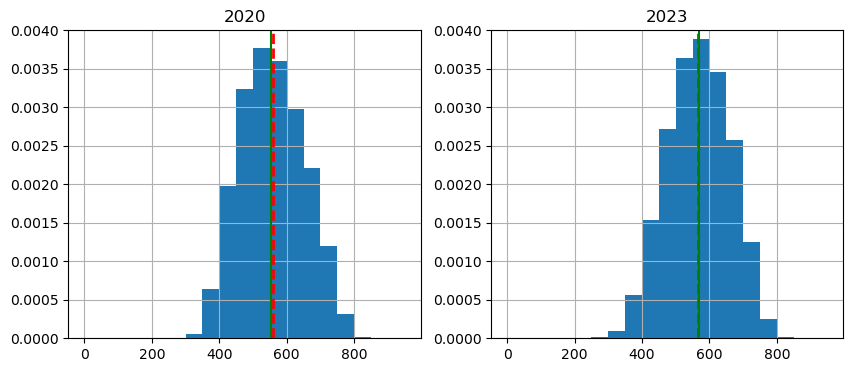

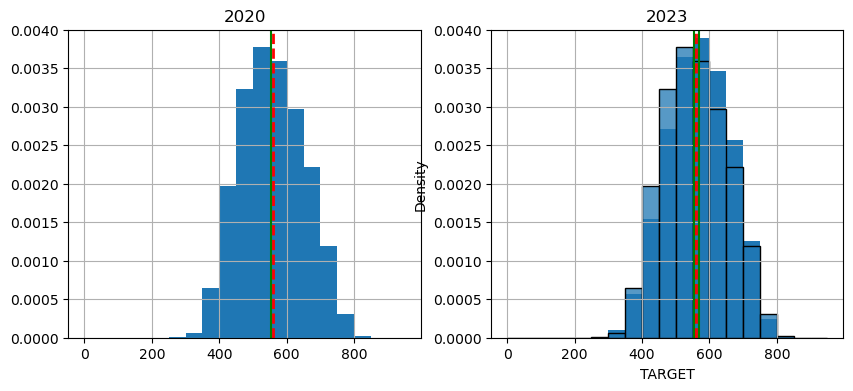

In [50]:
sb.histplot(x=dados2020['TARGET'], bins=bins,stat='density')
plt.axvline(dados2020['TARGET'].mean(), color='red', linestyle='--', label=f'Média: {dados2020['TARGET'].mean():.2f}',linewidth=2)
plt.axvline(dados2020['TARGET'].median(), color='green', linestyle='-', label=f'Mediana: {dados2020['TARGET'].median():.2f}')
plt.grid(True)
plt.show()

In [51]:
display(dados2020.groupby(['localizacao','tipo_escola']).TARGET.describe().round())
display(dados2023.groupby(['localizacao','tipo_escola']).TARGET.describe().round())


count   mean   std    min    25%    50%    75%  \
localizacao tipo_escola                                                      
Rural       Privada         574.0  591.0  77.0  382.0  537.0  593.0  646.0   
            Pública       13559.0  517.0  88.0  195.0  451.0  510.0  578.0   
Urbana      Privada      136038.0  623.0  84.0  228.0  566.0  630.0  686.0   
            Pública      345698.0  534.0  85.0  140.0  471.0  529.0  593.0   

                           max  
localizacao tipo_escola         
Rural       Privada      770.0  
            Pública      803.0  
Urbana      Privada      852.0  
            Pública      831.0

count   mean   std    min    25%    50%    75%  \
localizacao tipo_escola                                                      
Rural       Privada         892.0  587.0  84.0  350.0  528.0  593.0  652.0   
            Pública       20892.0  525.0  87.0  131.0  461.0  523.0  589.0   
Urbana      Privada      188227.0  632.0  78.0  218.0  582.0  641.0  690.0   
            Pública      454841.0  542.0  84.0   90.0  483.0  543.0  602.0   

                           max  
localizacao tipo_escola         
Rural       Privada      823.0  
            Pública      800.0  
Urbana      Privada      866.0  
            Pública      833.0

In [52]:
print(f'\n *Análise geral IFDM de 2020* \n {dados2020['IFDM'].describe()}')
print(f'\n *Análise geral IFDM de 2023* \n {dados2023['IFDM'].describe()}')
plt.figure(figsize=(10,4))
bins = np.linspace(0, 1, 21)
plt.subplot(1,2,1)
plt.hist(dados2020['IFDM'],density=True,bins=bins)
plt.axvline(0.641443, color='red', linestyle='--', label=f'Média: {0.641443:.2f}')
plt.axvline(0.665100, color='green', linestyle='-', label=f'Mediana: {0.665100:.2f}')
plt.title('2020')
plt.grid()
plt.subplot(1,2,2)
plt.hist(dados2023['IFDM'],density=True,bins=bins)
plt.axvline(0.698458, color='red', linestyle='--', label=f'Média: {0.698458:.2f}')
plt.axvline(0.722400, color='green', linestyle='-', label=f'Mediana: {0.722400:.2f}')
plt.title('2023')
plt.grid()


 *Análise geral IFDM de 2020* 
 count    491461.000000
mean          0.641438
std           0.128767
min           0.194500
25%           0.549300
50%           0.664600
75%           0.739700
max           0.865600
Name: IFDM, dtype: float64

 *Análise geral IFDM de 2023* 
 count    631998.000000
mean          0.698389
std           0.120387
min           0.148500
25%           0.620200
50%           0.722400
75%           0.793300
max           0.893200
Name: IFDM, dtype: float64


In [53]:
display(dados2020.groupby(['localizacao','tipo_escola']).IFDM.describe().round(3))
display(dados2023.groupby(['localizacao','tipo_escola']).IFDM.describe().round(3))

count   mean    std    min    25%    50%    75%  \
localizacao tipo_escola                                                       
Rural       Privada         571.0  0.632  0.131  0.256  0.513  0.694  0.738   
            Pública       13408.0  0.540  0.130  0.200  0.448  0.526  0.636   
Urbana      Privada      135365.0  0.692  0.104  0.240  0.631  0.716  0.781   
            Pública      342117.0  0.625  0.131  0.194  0.528  0.641  0.733   

                           max  
localizacao tipo_escola         
Rural       Privada      0.850  
            Pública      0.866  
Urbana      Privada      0.866  
            Pública      0.866

count   mean    std    min    25%    50%    75%  \
localizacao tipo_escola                                                       
Rural       Privada         861.0  0.681  0.122  0.325  0.577  0.740  0.784   
            Pública       19856.0  0.605  0.124  0.158  0.522  0.603  0.697   
Urbana      Privada      179775.0  0.745  0.095  0.247  0.678  0.767  0.827   
            Pública      431506.0  0.683  0.123  0.148  0.598  0.693  0.786   

                           max  
localizacao tipo_escola         
Rural       Privada      0.868  
            Pública      0.876  
Urbana      Privada      0.888  
            Pública      0.893

In [55]:
print(f'\n *Análise geral PIB de 2020* \n {dados2020['PIB_MUNICIPAL_PER_CAPITA'].describe()}')
print(f'\n *Análise geral PIB de 2023* \n {dados2023['PIB_MUNICIPAL_PER_CAPITA'].describe()}')
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(dados2020['PIB_MUNICIPAL_PER_CAPITA'],density=True,bins=30)
plt.axvline(0.698458, color='red', linestyle='--', label=f'Média: {0.698458:.2f}')
plt.axvline(0.722400, color='green', linestyle='-', label=f'Mediana: {0.722400:.2f}')
plt.grid()
plt.subplot(1,2,2)
plt.hist(dados2020['PIB_MUNICIPAL_PER_CAPITA'],density=True,bins=30)
plt.grid()


 *Análise geral PIB de 2020* 
 count    495869.00000
mean      36738.17493
std       27602.04497
min        4920.64000
25%       20407.26000
50%       29935.42000
75%       49122.79000
max      590594.94000
Name: PIB_MUNICIPAL_PER_CAPITA, dtype: float64

 *Análise geral PIB de 2023* 
 count    664852.000000
mean      54752.591190
std       44789.899451
min        7201.700000
25%       29205.900000
50%       44563.380000
75%       69460.170000
max      722441.520000
Name: PIB_MUNICIPAL_PER_CAPITA, dtype: float64


In [56]:
dados2023.sort_values('PIB_MUNICIPAL_PER_CAPITA', ascending=False).PIB_MUNICIPAL_PER_CAPITA.unique()[:20]

array([722441.52, 684319.23, 679714.48, 606740.73, 537982.68, 424535.26,
       409443.67, 388732.46, 382417.42, 377790.63, 369126.5 , 362455.53,
       348422.72, 335620.33, 330535.28, 330080.63, 329299.37, 325175.25,
       320476.29, 317824.61])

In [57]:
dados2023.sort_values('PIB_MUNICIPAL_PER_CAPITA', ascending=False).head(5)

,Unnamed: 0,sexo,cor_raca,tipo_escola,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,localizacao,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,internet,computador,grupo_social_1,grupo_social_2,renda,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM,Q024_NOME
26532,26532,F,Preta,Pública,Saquarema,330550,Urbana,503.4,403.5,501.5,383.7,440.0,Sim,Não,Grupo 3,Não sei,Sem renda,446.5475,722441.52,0.6389,NaN
68749,68749,F,Parda,Pública,Saquarema,330550,Urbana,471.7,652.1,584.5,670.9,940.0,Sim,Não,Grupo 4,Grupo 2,Até 1.320,693.0850,722441.52,0.6389,NaN
8999,8999,F,Branca,Pública,Saquarema,330550,Urbana,477.9,513.9,542.0,405.7,600.0,Sim,Não,Grupo 4,Grupo 4,5.280 até 6.600,524.9250,722441.52,0.6389,NaN
188318,188318,M,Parda,Pública,Saquarema,330550,Urbana,464.8,608.4,568.8,526.2,760.0,Sim,1,Grupo 3,Grupo 2,1.320 até 1.980,611.3200,722441.52,NaN,NaN
143769,143769,F,Branca,Privada,Saquarema,330550,Urbana,507.7,518.0,506.9,436.9,720.0,Sim,Não,Grupo 4,Grupo 4,9.240 até 10.560,552.2325,722441.52,0.6389,NaN


In [58]:
display(dados2020.groupby(['localizacao','tipo_escola']).PIB_MUNICIPAL_PER_CAPITA.describe().round(3))
display(dados2023.groupby(['localizacao','tipo_escola']).PIB_MUNICIPAL_PER_CAPITA.describe().round(3))

count       mean        std      min       25%  \
localizacao tipo_escola                                                      
Rural       Privada         574.0  51722.565  47137.746  6342.85  20302.19   
            Pública       13559.0  25880.716  23406.765  5558.67  11427.01   
Urbana      Privada      136038.0  41888.654  25281.047  6384.75  24740.43   
            Pública      345698.0  35112.347  28250.203  4920.64  18049.58   

                              50%       75%        max  
localizacao tipo_escola                                 
Rural       Privada      40058.99  69950.95  310898.86  
            Pública      17729.65  31290.27  295506.92  
Urbana      Privada      38691.55  51050.94  590594.94  
            Pública      28420.87  45595.65  590594.94

count       mean         std       min       25%  \
localizacao tipo_escola                                                        
Rural       Privada         892.0  73410.792  101789.696  11284.69  30640.46   
            Pública       20892.0  37825.564   38381.309   7701.32  16141.60   
Urbana      Privada      188227.0  63377.270   40413.149   9604.74  36449.37   
            Pública      454841.0  51924.348   45999.559   7201.70  25497.43   

                              50%       75%        max  
localizacao tipo_escola                                 
Rural       Privada      50310.32  78144.03  679714.48  
            Pública      26617.09  45271.91  722441.52  
Urbana      Privada      57528.91  78586.94  722441.52  
            Pública      41477.50  67371.97  722441.52

SEA BORN: Biblioteca que produz gráficos esteticamente melhores e riqueza de informações (y,x,hue)

SPEARMAN: Correlação para variáveis quali ordinais

### Análise da variável: TP_ESCOLA - Tipo de Escola ###



In [59]:
# --- LIMPEZA DOS DADOS ---

# Mantém apenas as linhas onde a escola NÃO é 'Não respondeu' E NÃO é NaN

dados2020 = dados2020[(dados2020['tipo_escola'] != 'Não respondeu') & (dados2020['tipo_escola'].notna())]
dados2023 = dados2023[(dados2023['tipo_escola'] != 'Não respondeu') & (dados2023['tipo_escola'].notna())]

,2020 (%),2023 (%)
tipo_escola,,
Pública,72.45,71.55
Privada,27.55,28.45


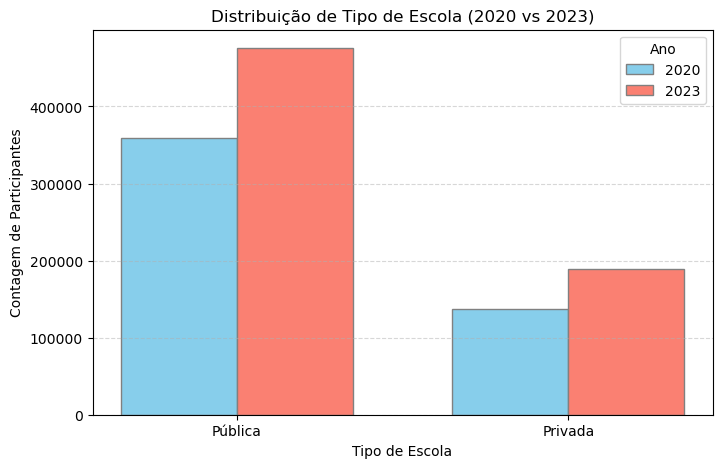

In [63]:
# 1. Preparando os Dados e a Tabela

pct_2020 = (dados2020['tipo_escola'].value_counts(normalize=True) * 100).round(2)
pct_2023 = (dados2023['tipo_escola'].value_counts(normalize=True) * 100).round(2)

tabela_porcentagem = pd.DataFrame({'2020 (%)': pct_2020, '2023 (%)': pct_2023})
display(tabela_porcentagem)

# Pegando a contagem absoluta para o gráfico

cont_2020 = dados2020['tipo_escola'].value_counts()
cont_2023 = dados2023['tipo_escola'].value_counts()


# 2. Configurando o Gráfico

# Pegamos as categorias direto da tabela para garantir que não falta nada
categorias = tabela_porcentagem.index.tolist()

# O SEGREDO ESTÁ AQUI: o reindex alinha os valores exatamente na mesma ordem, 
# e se um ano não tiver alguma categoria, ele preenche com 0!
valores20 = cont_2020.reindex(categorias, fill_value=0).values
valores23 = cont_2023.reindex(categorias, fill_value=0).values

# Definindo parâmetros e posições para as barras agrupadas
largura_barra = 0.35
r1 = np.arange(len(categorias))       
r2 = [x + largura_barra for x in r1]


# 3. Plot do Gráfico

plt.figure(figsize=(8, 5))

# Criando as barras + ajustes
plt.bar(r1, valores20, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2, valores23, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Distribuição de Tipo de Escola (2020 vs 2023)')
plt.ylabel('Contagem de Participantes')
plt.xlabel('Tipo de Escola')


# Colocando os nomes das categorias exatamente no meio das duas barras
plt.xticks([r + largura_barra/2 for r in r1], categorias)



plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')

plt.show()


### Interpretação

A análise da distribuição da variável **TP_ESCOLA (Tipo de Escola)** é fundamental para compreender as desigualdades estruturais no acesso ao ensino superior, especialmente para o curso de Direito, que é historicamente de alta concorrência. A literatura educacional aponta que alunos oriundos da rede privada tendem a apresentar um desempenho médio superior (MPE), reflexo direto de maiores investimentos em infraestrutura e metodologias focadas em exames de seleção. 

Ao comparar os anos de 2020 e 2023, buscamos identificar se o choque do ensino remoto emergencial durante a pandemia aprofundou esse abismo, visto que a rede pública enfrentou desafios severos de continuidade pedagógica nesse período. Dessa forma, o "Tipo de Escola" consolida-se como uma variável preditiva (feature) de alto impacto para explicar a variância nas notas dos candidatos.

___

### Análise da variável: Q024 (Computador em Casa) ###



,2020 (%),2023 (%)
computador,,
1,42.96,36.51
2,12.67,12.17
3,5.07,5.20
4+,2.57,2.78
Não,36.73,43.33


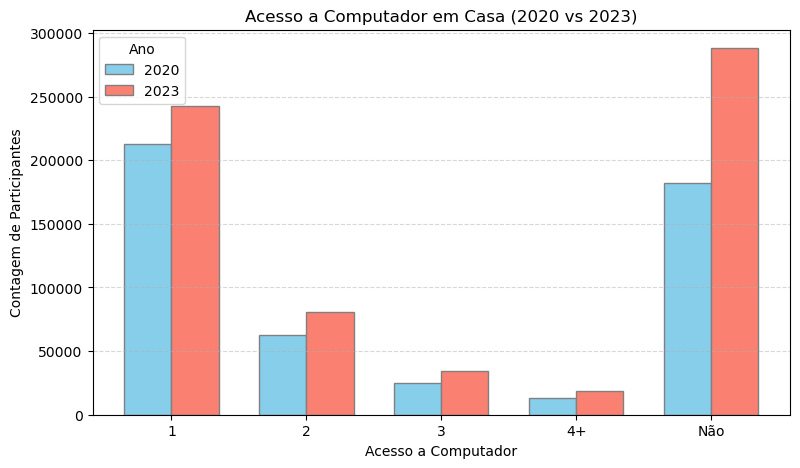

In [62]:
# 1. Preparando os Dados + Tabela

pct_2020_pc = (dados2020['computador'].value_counts(normalize=True) * 100).round(2)
pct_2023_pc = (dados2023['computador'].value_counts(normalize=True) * 100).round(2)

tabela_porcentagem_pc = pd.DataFrame({'2020 (%)': pct_2020_pc, '2023 (%)': pct_2023_pc})
display(tabela_porcentagem_pc)

# Contagem para o gráfico
cont_2020_pc = dados2020['computador'].value_counts()
cont_2023_pc = dados2023['computador'].value_counts()



# 2. Configurando o Gráfico

categorias_pc = tabela_porcentagem_pc.index.tolist()
valores20_pc = cont_2020_pc.reindex(categorias_pc, fill_value=0).values
valores23_pc = cont_2023_pc.reindex(categorias_pc, fill_value=0).values

largura_barra = 0.35
r1_pc = np.arange(len(categorias_pc))
r2_pc = [x + largura_barra for x in r1_pc]



# 3. Plot do Gráfico
plt.figure(figsize=(9, 5))

plt.bar(r1_pc, valores20_pc, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_pc, valores23_pc, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Acesso a Computador em Casa (2020 vs 2023)')
plt.ylabel('Contagem de Participantes')
plt.xlabel('Acesso a Computador')

# Se os textos forem curtos (ex: "Sim" e "Não"), pode deixar rotation=0
plt.xticks([r + largura_barra/2 for r in r1_pc], categorias_pc, rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')

plt.show()

### Interpretação

A análise da variável **Q024 (Acesso a Computador em casa)** ganha contornos cruciais nesta Análise Exploratória, sobretudo pela janela temporal escolhida (2020 vs 2023). Durante a pandemia em 2020, a posse de equipamentos tecnológicos deixou de ser apenas um facilitador de estudos para se tornar a condição primária de acesso à educação básica. 

Espera-se que o grupo de candidatos sem acesso a computador apresente uma Média Ponderada (MPE) consideravelmente inferior, refletindo o prejuízo da exclusão digital. Além do viés tecnológico, esta variável atua como um forte *proxy* (indicador indireto) do poder aquisitivo e da infraestrutura domiciliar da família. Observar a evolução temporal dessa posse até 2023 nos ajuda a medir se o retorno ao ensino presencial conseguiu mitigar os danos dessa lacuna tecnológica inicial no desempenho dos vestibulandos de Direito.

___